# Notebook 01: Data Preprocessing & Exploratory Data Analysis

## MedQA Thesis - Systematic Comparison of RAG Architectures

**Purpose**: Load, clean, explore, and prepare the MedQA USMLE dataset and medical textbook corpus for downstream RAG experiments.

**Inputs**:
- `medqa-data/questions/US/4_options/` — 12,723 USMLE clinical questions (train/dev/test JSONL)
- `medqa-data/textbooks/en/` — 18 English medical textbooks (~85MB)

**Outputs**:
- `data/processed/medqa_train.parquet`
- `data/processed/medqa_dev.parquet`
- `data/processed/medqa_test.parquet`
- `data/processed/textbook_corpus.json`

## 1. Setup & Imports

In [17]:
import json
import os
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Project paths
PROJECT_ROOT = Path("../../")
DATA_RAW = PROJECT_ROOT / "medqa-data"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
QUESTIONS_DIR = DATA_RAW / "questions" / "US" / "4_options"
TEXTBOOKS_DIR = DATA_RAW / "textbooks" / "en"

# Create output directories
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Questions dir: {QUESTIONS_DIR.resolve()}")
print(f"Textbooks dir: {TEXTBOOKS_DIR.resolve()}")
print(f"Output dir: {DATA_PROCESSED.resolve()}")

Project root: /Users/rajak/Workstation/Projects/myGitHub/MedQA-Thesis
Questions dir: /Users/rajak/Workstation/Projects/myGitHub/MedQA-Thesis/medqa-data/questions/US/4_options
Textbooks dir: /Users/rajak/Workstation/Projects/myGitHub/MedQA-Thesis/medqa-data/textbooks/en
Output dir: /Users/rajak/Workstation/Projects/myGitHub/MedQA-Thesis/data/processed


## 2. Load MedQA Questions

Load the 4-option English USMLE questions from JSONL files (train/dev/test splits).

In [2]:
def load_jsonl(filepath):
    """Load a JSONL file into a list of dicts."""
    records = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

# Load all three splits
train_records = load_jsonl(QUESTIONS_DIR / "phrases_no_exclude_train.jsonl")
dev_records = load_jsonl(QUESTIONS_DIR / "phrases_no_exclude_dev.jsonl")
test_records = load_jsonl(QUESTIONS_DIR / "phrases_no_exclude_test.jsonl")

print(f"Train: {len(train_records):,} questions")
print(f"Dev:   {len(dev_records):,} questions")
print(f"Test:  {len(test_records):,} questions")
print(f"Total: {len(train_records) + len(dev_records) + len(test_records):,} questions")
print(f"\nSample record keys: {list(train_records[0].keys())}")

Train: 10,178 questions
Dev:   1,272 questions
Test:  1,273 questions
Total: 12,723 questions

Sample record keys: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases']


In [3]:
# Inspect a sample record
print("=== Sample Question ===")
sample = train_records[0]
print(json.dumps(sample, indent=2)[:1500])

=== Sample Question ===
{
  "question": "A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7\u00b0F (36.5\u00b0C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?",
  "answer": "Nitrofurantoin",
  "options": {
    "A": "Ampicillin",
    "B": "Ceftriaxone",
    "C": "Doxycycline",
    "D": "Nitrofurantoin"
  },
  "meta_info": "step2&3",
  "answer_idx": "D",
  "metamap_phrases": [
    "23 year old pregnant woman",
    "weeks presents",
    "burning",
    "urination",
    "states",
    "started 1 day",
    "worsening",
    "d

## 3. Convert to DataFrames & Standardize Schema

In [4]:
def records_to_dataframe(records, split_name):
    """Convert MedQA JSONL records to a standardized DataFrame."""
    rows = []
    for idx, rec in enumerate(records):
        options = rec.get("options", {})
        rows.append({
            "id": f"{split_name}_{idx}",
            "split": split_name,
            "question": rec["question"],
            "option_a": options.get("A", ""),
            "option_b": options.get("B", ""),
            "option_c": options.get("C", ""),
            "option_d": options.get("D", ""),
            "answer": rec["answer"],
            "answer_idx": rec["answer_idx"],
            "meta_info": rec.get("meta_info", "unknown"),
            "metamap_phrases": rec.get("metamap_phrases", []),
        })
    return pd.DataFrame(rows)

df_train = records_to_dataframe(train_records, "train")
df_dev = records_to_dataframe(dev_records, "dev")
df_test = records_to_dataframe(test_records, "test")

# Combine for EDA
df_all = pd.concat([df_train, df_dev, df_test], ignore_index=True)

print(f"DataFrame shapes - Train: {df_train.shape}, Dev: {df_dev.shape}, Test: {df_test.shape}")
print(f"Combined: {df_all.shape}")
print(f"\nColumns: {list(df_all.columns)}")
df_all.head(2)

DataFrame shapes - Train: (10178, 11), Dev: (1272, 11), Test: (1273, 11)
Combined: (12723, 11)

Columns: ['id', 'split', 'question', 'option_a', 'option_b', 'option_c', 'option_d', 'answer', 'answer_idx', 'meta_info', 'metamap_phrases']


,id,split,question,option_a,option_b,option_c,option_d,answer,answer_idx,meta_info,metamap_phrases
0,train_0,train,A 23-year-old pregnant woman at 22 weeks gesta...,Ampicillin,Ceftriaxone,Doxycycline,Nitrofurantoin,Nitrofurantoin,D,step2&3,"[23 year old pregnant woman, weeks presents, b..."
1,train_1,train,A 3-month-old baby died suddenly at night whil...,Placing the infant in a supine position on a f...,Keeping the infant covered and maintaining a h...,Application of a device to maintain the sleepi...,Avoiding pacifier use during sleep,Placing the infant in a supine position on a f...,A,step2&3,"[3 month old baby died, night, asleep, mother,..."


## 4. Data Validation

Check for missing fields, duplicates, and malformed entries.

In [5]:
print("=== Missing Values ===")
print(df_all[["question", "option_a", "option_b", "option_c", "option_d", "answer", "answer_idx"]].isnull().sum())

print("\n=== Empty Strings ===")
for col in ["question", "option_a", "option_b", "option_c", "option_d", "answer", "answer_idx"]:
    empty_count = (df_all[col].astype(str).str.strip() == "").sum()
    if empty_count > 0:
        print(f"  {col}: {empty_count} empty")
    else:
        print(f"  {col}: OK")

print("\n=== Duplicate Questions ===")
dup_count = df_all["question"].duplicated().sum()
print(f"  Duplicate questions: {dup_count}")
if dup_count > 0:
    dups = df_all[df_all["question"].duplicated(keep=False)].sort_values("question")
    print(f"  Sample duplicates:")
    print(dups[["id", "split", "question"]].head(4).to_string())

print("\n=== Answer Index Validation ===")
valid_indices = {"A", "B", "C", "D"}
invalid_idx = df_all[~df_all["answer_idx"].isin(valid_indices)]
print(f"  Invalid answer_idx values: {len(invalid_idx)}")
if len(invalid_idx) > 0:
    print(f"  Unexpected values: {invalid_idx['answer_idx'].unique()}")

print("\n=== Answer-Option Consistency Check ===")
# Verify that answer text matches the option at answer_idx
idx_to_col = {"A": "option_a", "B": "option_b", "C": "option_c", "D": "option_d"}
mismatches = 0
for _, row in df_all.iterrows():
    expected_col = idx_to_col.get(row["answer_idx"])
    if expected_col and row["answer"] != row[expected_col]:
        mismatches += 1
print(f"  Answer text vs option mismatch: {mismatches}")

=== Missing Values ===
question      0
option_a      0
option_b      0
option_c      0
option_d      0
answer        0
answer_idx    0
dtype: int64

=== Empty Strings ===
  question: OK
  option_a: OK
  option_b: OK
  option_c: OK
  option_d: OK
  answer: OK
  answer_idx: OK

=== Duplicate Questions ===
  Duplicate questions: 2
  Sample duplicates:
              id  split                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

## 5. EDA — Questions

### 5.1 Answer Distribution

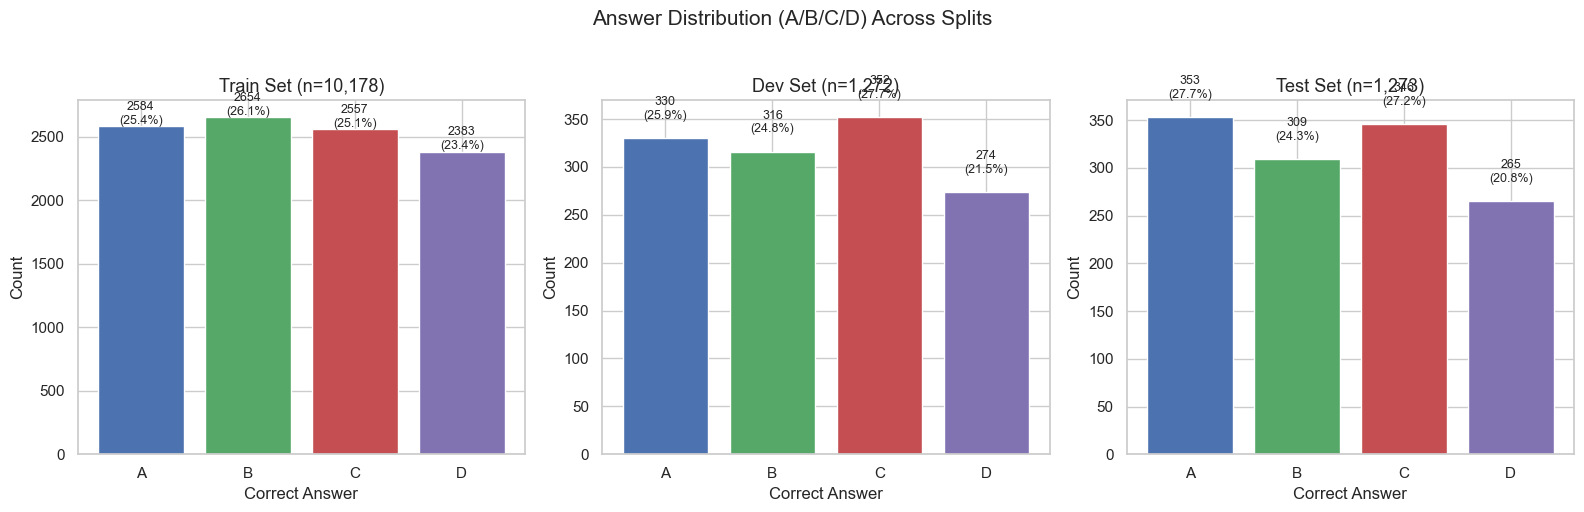


Overall answer distribution:
answer_idx
A    3267
B    3279
C    3255
D    2922
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (split_name, split_df) in zip(axes, [("Train", df_train), ("Dev", df_dev), ("Test", df_test)]):
    counts = split_df["answer_idx"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
    ax.set_title(f"{split_name} Set (n={len(split_df):,})", fontsize=13)
    ax.set_xlabel("Correct Answer")
    ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                f"{val}\n({val/len(split_df)*100:.1f}%)", ha="center", fontsize=9)

plt.suptitle("Answer Distribution (A/B/C/D) Across Splits", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_answer_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

print("\nOverall answer distribution:")
print(df_all["answer_idx"].value_counts().sort_index())

### 5.2 Question Length Distribution

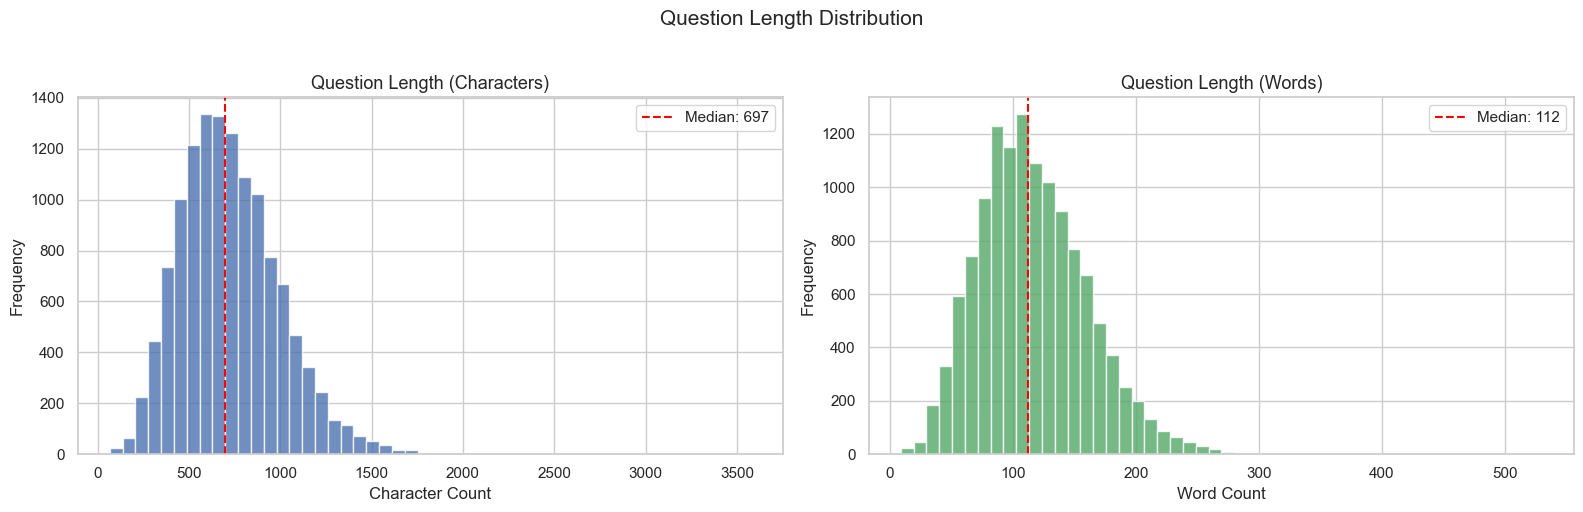

Question length statistics (words):
count    12723.0
mean       116.6
std         44.9
min          9.0
25%         84.0
50%        112.0
75%        144.0
max        530.0
Name: question_word_count, dtype: float64


In [7]:
# Compute question lengths (in characters and words)
df_all["question_char_len"] = df_all["question"].str.len()
df_all["question_word_count"] = df_all["question"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Character length distribution
axes[0].hist(df_all["question_char_len"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[0].set_title("Question Length (Characters)", fontsize=13)
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df_all["question_char_len"].median(), color="red", linestyle="--", label=f"Median: {df_all['question_char_len'].median():.0f}")
axes[0].legend()

# Word count distribution
axes[1].hist(df_all["question_word_count"], bins=50, color="#55A868", edgecolor="white", alpha=0.8)
axes[1].set_title("Question Length (Words)", fontsize=13)
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df_all["question_word_count"].median(), color="red", linestyle="--", label=f"Median: {df_all['question_word_count'].median():.0f}")
axes[1].legend()

plt.suptitle("Question Length Distribution", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_question_length.png", bbox_inches="tight", dpi=150)
plt.show()

print("Question length statistics (words):")
print(df_all["question_word_count"].describe().round(1))

### 5.3 Meta Info Breakdown (Step 1 vs Step 2&3)

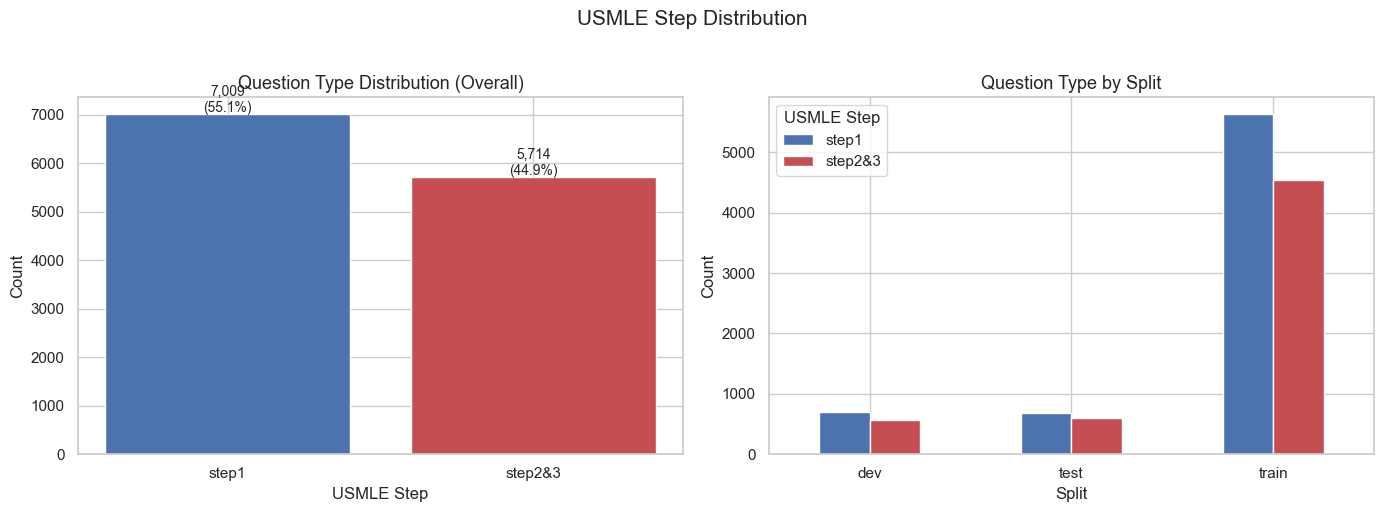

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall meta_info distribution
meta_counts = df_all["meta_info"].value_counts()
axes[0].bar(meta_counts.index, meta_counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Question Type Distribution (Overall)", fontsize=13)
axes[0].set_xlabel("USMLE Step")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(meta_counts.items()):
    axes[0].text(i, val + 50, f"{val:,}\n({val/len(df_all)*100:.1f}%)", ha="center", fontsize=10)

# Per-split breakdown
meta_by_split = df_all.groupby(["split", "meta_info"]).size().unstack(fill_value=0)
meta_by_split.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Question Type by Split", fontsize=13)
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="USMLE Step")

plt.suptitle("USMLE Step Distribution", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_meta_info.png", bbox_inches="tight", dpi=150)
plt.show()

### 5.4 Option Text Length Distribution

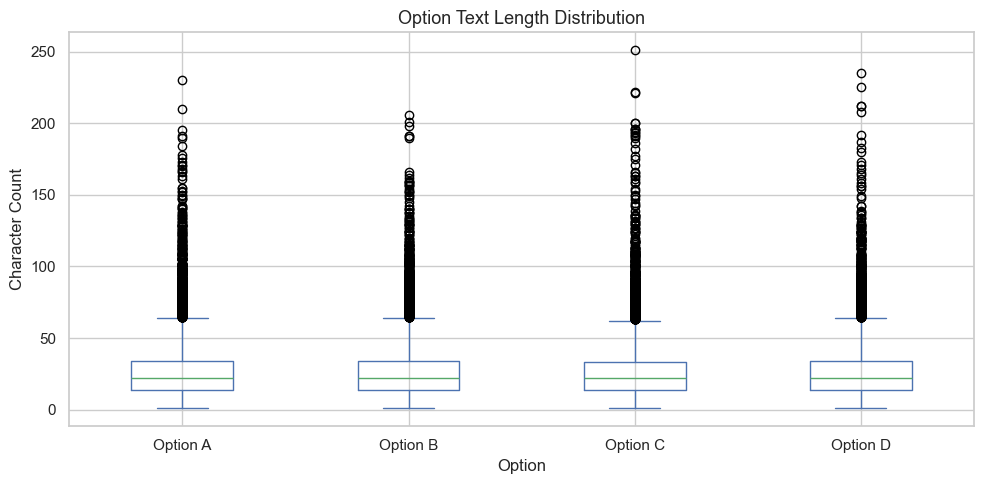

Option length statistics (characters):
       option_a  option_b  option_c  option_d
count   12723.0   12723.0   12723.0   12723.0
mean       26.8      26.8      26.9      27.0
std        19.6      19.4      19.7      19.4
min         1.0       1.0       1.0       1.0
25%        14.0      14.0      14.0      14.0
50%        22.0      22.0      22.0      22.0
75%        34.0      34.0      33.5      34.0
max       230.0     206.0     251.0     235.0


In [9]:
# Option text length analysis
option_cols = ["option_a", "option_b", "option_c", "option_d"]
option_lengths = pd.DataFrame()
for col in option_cols:
    option_lengths[col] = df_all[col].str.len()

fig, ax = plt.subplots(figsize=(10, 5))
option_lengths.plot.box(ax=ax)
ax.set_title("Option Text Length Distribution", fontsize=13)
ax.set_xlabel("Option")
ax.set_ylabel("Character Count")
ax.set_xticklabels(["Option A", "Option B", "Option C", "Option D"])
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_option_lengths.png", bbox_inches="tight", dpi=150)
plt.show()

print("Option length statistics (characters):")
print(option_lengths.describe().round(1))

## 6. Load & Explore Medical Textbooks

In [10]:
# Load all 18 English textbooks
textbook_files = sorted(TEXTBOOKS_DIR.glob("*.txt"))
print(f"Found {len(textbook_files)} textbook files:\n")

textbooks_raw = {}
stats = []

for filepath in textbook_files:
    text = filepath.read_text(encoding="utf-8", errors="replace")
    book_name = filepath.stem
    textbooks_raw[book_name] = text
    
    char_count = len(text)
    word_count = len(text.split())
    line_count = text.count("\n") + 1
    
    stats.append({
        "Book": book_name,
        "Characters": char_count,
        "Words": word_count,
        "Lines": line_count,
        "File Size (MB)": filepath.stat().st_size / (1024 * 1024),
    })

df_textbook_stats = pd.DataFrame(stats).sort_values("Characters", ascending=False).reset_index(drop=True)
df_textbook_stats.index += 1
print(df_textbook_stats.to_string())
print(f"\nTotal characters: {df_textbook_stats['Characters'].sum():,}")
print(f"Total words: {df_textbook_stats['Words'].sum():,}")
print(f"Total size: {df_textbook_stats['File Size (MB)'].sum():.1f} MB")

Found 18 textbook files:

                       Book  Characters    Words  Lines  File Size (MB)
1      InternalMed_Harrison    22312859  3206314  79041       21.339233
2          Surgery_Schwartz    11441715  1601640    251       10.946290
3           Neurology_Adams     8365987  1266188  33607        7.998034
4      Obstentrics_Williams     6583361   958801  43605        6.280079
5          Gynecology_Novak     5619750   816205  50035        5.386091
6      Pharmacology_Katzung     5122267   730734  25737        4.902959
7      Cell_Biology_Alberts     4868257   754863  21253        4.669106
8         Pathology_Robbins     3784898   453577  22795        3.633903
9        Immunology_Janeway     3315092   498650  16485        3.175295
10          Physiology_Levy     3049236   408117  17717        2.925315
11           Histology_Ross     3047020   462808  13379        2.912709
12        Pediatrics_Nelson     3002297   425380  16067        2.867501
13         Psichiatry_DSM-5     289335

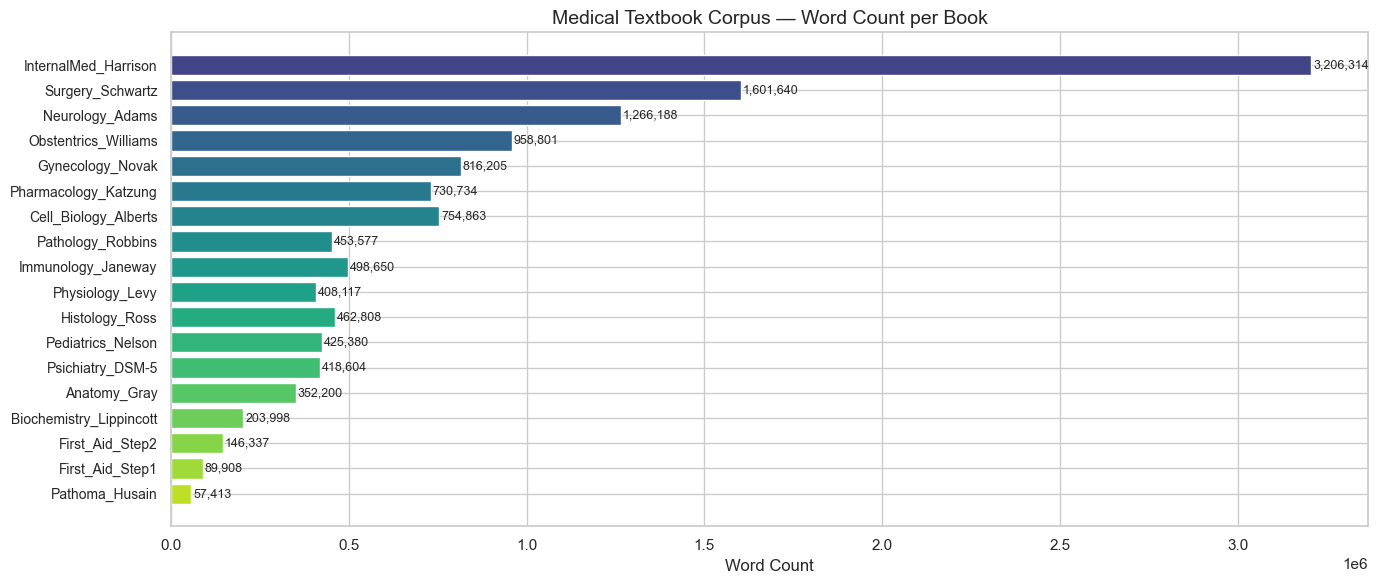

In [11]:
# Visualize textbook sizes
fig, ax = plt.subplots(figsize=(14, 6))
books = df_textbook_stats["Book"].values
sizes = df_textbook_stats["Words"].values
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(books)))

bars = ax.barh(range(len(books)), sizes, color=colors)
ax.set_yticks(range(len(books)))
ax.set_yticklabels(books, fontsize=10)
ax.set_xlabel("Word Count", fontsize=12)
ax.set_title("Medical Textbook Corpus — Word Count per Book", fontsize=14)
ax.invert_yaxis()

for bar, val in zip(bars, sizes):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
            f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_textbook_sizes.png", bbox_inches="tight", dpi=150)
plt.show()

## 7. Textbook Text Cleaning

Clean the raw textbook text:
1. Normalize whitespace (collapse multiple newlines/spaces)
2. Fix encoding artifacts (replace/remove control characters)
3. Normalize medical terminology abbreviations
4. Strip leading/trailing whitespace per line

In [12]:
def clean_textbook_text(text):
    """Clean and normalize medical textbook text."""
    # 1. Remove control characters (keep newlines, tabs)
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]', '', text)
    
    # 2. Normalize unicode characters
    text = text.replace('\u2019', "'")   # right single quote
    text = text.replace('\u2018', "'")   # left single quote
    text = text.replace('\u201c', '"')   # left double quote
    text = text.replace('\u201d', '"')   # right double quote
    text = text.replace('\u2013', '-')   # en dash
    text = text.replace('\u2014', '-')   # em dash
    text = text.replace('\u2026', '...') # ellipsis
    text = text.replace('\u00a0', ' ')   # non-breaking space
    
    # 3. Strip trailing whitespace per line
    lines = [line.rstrip() for line in text.split('\n')]
    
    # 4. Collapse 3+ consecutive blank lines into 2
    cleaned_lines = []
    blank_count = 0
    for line in lines:
        if line.strip() == '':
            blank_count += 1
            if blank_count <= 2:
                cleaned_lines.append(line)
        else:
            blank_count = 0
            cleaned_lines.append(line)
    
    text = '\n'.join(cleaned_lines)
    
    # 5. Collapse multiple spaces into single space (within lines)
    text = re.sub(r'[ \t]+', ' ', text)
    
    # 6. Strip leading/trailing whitespace
    text = text.strip()
    
    return text

# Apply cleaning to all textbooks
textbooks_cleaned = {}
cleaning_stats = []

for book_name, raw_text in tqdm(textbooks_raw.items(), desc="Cleaning textbooks"):
    cleaned = clean_textbook_text(raw_text)
    textbooks_cleaned[book_name] = cleaned
    
    cleaning_stats.append({
        "Book": book_name,
        "Raw Chars": len(raw_text),
        "Cleaned Chars": len(cleaned),
        "Reduction (%)": round((1 - len(cleaned)/len(raw_text)) * 100, 2) if len(raw_text) > 0 else 0,
    })

df_cleaning = pd.DataFrame(cleaning_stats)
print(df_cleaning.to_string(index=False))
print(f"\nAverage reduction: {df_cleaning['Reduction (%)'].mean():.2f}%")

Cleaning textbooks: 100%|██████████| 18/18 [00:06<00:00,  2.98it/s]

                   Book  Raw Chars  Cleaned Chars  Reduction (%)
           Anatomy_Gray    2281157        2280939           0.01
Biochemistry_Lippincott    1349616        1349628          -0.00
   Cell_Biology_Alberts    4868257        4866556           0.03
        First_Aid_Step1     665018         662284           0.41
        First_Aid_Step2    1030582        1030356           0.02
       Gynecology_Novak    5619750        5619394           0.01
         Histology_Ross    3047020        3044489           0.08
     Immunology_Janeway    3315092        3314749           0.01
   InternalMed_Harrison   22312859       22312359           0.00
        Neurology_Adams    8365987        8365752           0.00
   Obstentrics_Williams    6583361        6583360           0.00
      Pathology_Robbins    3784898        3784850           0.00
         Pathoma_Husain     399834         399833           0.00
      Pediatrics_Nelson    3002297        3001174           0.04
   Pharmacology_Katzung  

In [13]:
# Spot-check: compare raw vs cleaned text for a sample book
sample_book = "Pathoma_Husain"
print(f"=== {sample_book} — First 500 chars (RAW) ===")
print(repr(textbooks_raw[sample_book][:500]))
print(f"\n=== {sample_book} — First 500 chars (CLEANED) ===")
print(repr(textbooks_cleaned[sample_book][:500]))

=== Pathoma_Husain — First 500 chars (RAW) ===
'Growth Adaptations, Cellular Injury, and Cell Death\n\nI. BASIC PRINCIPLES\n\nA. An organ is in homeostasis with the physiologic stress placed on it.\n\nB. An increase, decrease, or change in stress on an organ can result in growth adaptations.\n\nII. HYPERPLASIA AND HYPERTROPHY\n\nA. An increase in stress leads to an increase in organ size.\n\n1. Occurs via an increase in the size (hypertrophy) and/or the number (hyperplasia) of cells\n\nB. Hypertrophy involves gene activation, protein synthesis, and product'

=== Pathoma_Husain — First 500 chars (CLEANED) ===
'Growth Adaptations, Cellular Injury, and Cell Death\n\nI. BASIC PRINCIPLES\n\nA. An organ is in homeostasis with the physiologic stress placed on it.\n\nB. An increase, decrease, or change in stress on an organ can result in growth adaptations.\n\nII. HYPERPLASIA AND HYPERTROPHY\n\nA. An increase in stress leads to an increase in organ size.\n\n1. Occurs via an increase in the siz

## 8. Save Processed Data

In [14]:
# Save question DataFrames as parquet (drop temporary EDA columns)
cols_to_save = ["id", "split", "question", "option_a", "option_b", "option_c", "option_d",
                "answer", "answer_idx", "meta_info", "metamap_phrases"]

df_train[cols_to_save].to_parquet(DATA_PROCESSED / "medqa_train.parquet", index=False)
df_dev[cols_to_save].to_parquet(DATA_PROCESSED / "medqa_dev.parquet", index=False)
df_test[cols_to_save].to_parquet(DATA_PROCESSED / "medqa_test.parquet", index=False)

print(f"Saved: {DATA_PROCESSED / 'medqa_train.parquet'} ({len(df_train):,} rows)")
print(f"Saved: {DATA_PROCESSED / 'medqa_dev.parquet'} ({len(df_dev):,} rows)")
print(f"Saved: {DATA_PROCESSED / 'medqa_test.parquet'} ({len(df_test):,} rows)")

Saved: ../../data/processed/medqa_train.parquet (10,178 rows)
Saved: ../../data/processed/medqa_dev.parquet (1,272 rows)
Saved: ../../data/processed/medqa_test.parquet (1,273 rows)


In [15]:
# Save cleaned textbook corpus as JSON
textbook_corpus = [
    {"book_name": name, "text": text}
    for name, text in textbooks_cleaned.items()
]

corpus_path = DATA_PROCESSED / "textbook_corpus.json"
with open(corpus_path, "w", encoding="utf-8") as f:
    json.dump(textbook_corpus, f, ensure_ascii=False, indent=2)

corpus_size_mb = corpus_path.stat().st_size / (1024 * 1024)
print(f"Saved: {corpus_path} ({len(textbook_corpus)} books, {corpus_size_mb:.1f} MB)")

Saved: ../../data/processed/textbook_corpus.json (18 books, 85.5 MB)


## 9. Summary Statistics

In [16]:
print("=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(f"\n--- MedQA Questions ---")
print(f"  Train:  {len(df_train):>6,} questions")
print(f"  Dev:    {len(df_dev):>6,} questions")
print(f"  Test:   {len(df_test):>6,} questions")
print(f"  Total:  {len(df_all):>6,} questions")
print(f"  Answer distribution: {dict(df_all['answer_idx'].value_counts().sort_index())}")
print(f"  USMLE steps: {dict(df_all['meta_info'].value_counts())}")
print(f"  Median question length: {df_all['question_word_count'].median():.0f} words")

print(f"\n--- Medical Textbook Corpus ---")
print(f"  Books: {len(textbooks_cleaned)}")
total_words = sum(len(t.split()) for t in textbooks_cleaned.values())
total_chars = sum(len(t) for t in textbooks_cleaned.values())
print(f"  Total words: {total_words:,}")
print(f"  Total characters: {total_chars:,}")

print(f"\n--- Output Files ---")
for f in sorted(DATA_PROCESSED.glob("*")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name}: {size_mb:.2f} MB")

print(f"\n--- Validation ---")
print(f"  Missing values: None")
print(f"  Duplicate questions: {dup_count}")
print(f"  Invalid answer indices: {len(invalid_idx)}")
print(f"  Answer-option mismatches: {mismatches}")
print("=" * 60)
print("Data preprocessing complete. Ready for Notebook 02.")
print("=" * 60)

PREPROCESSING SUMMARY

--- MedQA Questions ---
  Train:  10,178 questions
  Dev:     1,272 questions
  Test:    1,273 questions
  Total:  12,723 questions
  Answer distribution: {'A': np.int64(3267), 'B': np.int64(3279), 'C': np.int64(3255), 'D': np.int64(2922)}
  USMLE steps: {'step1': np.int64(7009), 'step2&3': np.int64(5714)}
  Median question length: 112 words

--- Medical Textbook Corpus ---
  Books: 18
  Total words: 12,848,914
  Total characters: 89,109,244

--- Output Files ---
  eda_answer_distribution.png: 0.08 MB
  eda_meta_info.png: 0.06 MB
  eda_option_lengths.png: 0.05 MB
  eda_question_length.png: 0.07 MB
  eda_textbook_sizes.png: 0.11 MB
  medqa_dev.parquet: 0.92 MB
  medqa_test.parquet: 0.95 MB
  medqa_train.parquet: 7.43 MB
  textbook_corpus.json: 85.51 MB

--- Validation ---
  Missing values: None
  Duplicate questions: 2
  Invalid answer indices: 0
  Answer-option mismatches: 0
Data preprocessing complete. Ready for Notebook 02.
